In [105]:
import anndata as ad
import networkx as nx
import numpy as np
import pandas as pd
import scglue
import seaborn as sns
from IPython import display
from matplotlib import rcParams
from networkx.algorithms.bipartite import biadjacency_matrix
from networkx.drawing.nx_agraph import graphviz_layout

In [106]:
scglue.plot.set_publication_params()
rcParams['figure.figsize'] = (4, 4)

In [107]:
rna = ad.read_h5ad("MISAR-rna-emb.h5ad")
atac = ad.read_h5ad("MISAR-atac-emb.h5ad")
guidance_hvf = nx.read_graphml("MISAR-guidance-hvf.graphml.gz")

In [108]:
rna.var['chromStart'] = rna.var['chromStart'].astype(int)
rna.var['chromEnd'] = rna.var['chromEnd'].astype(int)

In [109]:
rna.var

,n_cells,highly_variable,highly_variable_rank,means,variances,variances_norm,mean,std,chrom,chromStart,...,thickEnd,itemRgb,blockCount,blockSizes,blockStarts,gene_id,gene_type,mgi_id,havana_gene,tag
genes,,,,,,,,,,,,,,,,,,,,,
Xkr4,1419,False,NaN,1.522311,2.618041,0.977773,0.675789,0.558691,chr1,3205900,...,.,.,.,.,.,ENSMUSG00000051951.5,protein_coding,MGI:3528744,OTTMUSG00000026353.2,NaN
Gm1992,72,False,NaN,0.034758,0.035445,1.000773,0.021575,0.127308,chr1,3466586,...,.,.,.,.,.,ENSMUSG00000089699.1,antisense,MGI:3780162,OTTMUSG00000026352.1,NaN
Gm19938,104,False,NaN,0.050258,0.050574,0.981246,0.026800,0.127694,chr1,3647308,...,.,.,.,.,.,ENSMUSG00000102331.1,sense_intronic,MGI:5012123,OTTMUSG00000049924.1,NaN
Gm37381,81,False,NaN,0.038046,0.036616,0.942908,0.024163,0.133646,chr1,3905738,...,.,.,.,.,.,ENSMUSG00000102343.1,lincRNA,MGI:5610609,OTTMUSG00000049934.1,NaN
Rp1,326,False,NaN,0.175200,0.194385,1.032134,0.100130,0.262206,chr1,3999556,...,.,.,.,.,.,ENSMUSG00000025900.13,protein_coding,MGI:1341105,OTTMUSG00000049985.3,overlapping_locus
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Csprs,67,False,NaN,0.031940,0.031874,0.980778,0.018880,0.113715,GL456221.1,111571,...,.,.,.,.,.,ENSMUSG00000062783.2,protein_coding,MGI:1891441,NaN,NaN
Vamp7,64,True,2900.0,0.031470,0.033314,1.040650,0.018747,0.117191,GL456233.1,10737,...,.,.,.,.,.,ENSMUSG00000051412.6,protein_coding,MGI:1096399,NaN,NaN
Tmlhe,312,False,NaN,0.166275,0.183806,1.032140,0.099596,0.266841,GL456233.1,159646,...,.,.,.,.,.,ENSMUSG00000079834.2,protein_coding,MGI:2180203,NaN,NaN


In [110]:
rna.var["name"] = rna.var_names
atac.var["name"] = atac.var_names

In [111]:
genes = rna.var.query("highly_variable").index
peaks = atac.var.query("highly_variable").index

In [112]:
features = pd.Index(np.concatenate([rna.var_names, atac.var_names]))
feature_embeddings = np.concatenate([rna.varm["X_glue"], atac.varm["X_glue"]])

In [113]:
skeleton = guidance_hvf.edge_subgraph(
    e for e, attr in dict(guidance_hvf.edges).items()
    if attr["type"] == "fwd"
).copy()

In [114]:
reginf = scglue.genomics.regulatory_inference(
    features, feature_embeddings,
    skeleton=skeleton, random_state=0
)

regulatory_inference: 100%|██████████| 14600/14600 [00:00<00:00, 81587.22it/s]


In [115]:
gene2peak = reginf.edge_subgraph(
    e for e, attr in dict(reginf.edges).items()
    if attr["qval"] < 0.05
)

In [116]:
nx.write_graphml(gene2peak, "MISAR_E18.5-S1_gene_peak_network.graphml")

In [117]:
scglue.genomics.Bed(atac.var).write_bed("peaks.bed", ncols=3)
scglue.genomics.write_links(
    gene2peak,
    scglue.genomics.Bed(rna.var).strand_specific_start_site(),
    scglue.genomics.Bed(atac.var),
    "gene2peak.links", keep_attrs=["score"]
)

In [119]:
def get_top_peaks_for_outflows(gene2peak, outflows, top_k=5, score_key="score"):
    """
    从 gene2peak 图中为每个 outflow 基因提取与其相连的 top-k peaks，
    按照 edge attribute 中的 score 排序。

    参数
    ----
    gene2peak : networkx.Graph 或 networkx.DiGraph
        代表 gene-peak regulatory links 的图，边上有 score 属性。
    outflows : list
        需要提取的 outflow 基因列表。
    top_k : int, 默认 5
        每个 outflow 选取的 top peaks 数量。
    score_key : str, 默认 "score"
        用于排序的边属性键名。

    返回
    ----
    dict
        {outflow_gene: [peak1, peak2, ...]} 的字典
    """
    
    outflow_peaks_dict = {}

    for outflow in outflows:
        if outflow not in gene2peak:
            continue

        # 所有相关边：(u, v, attr)
        edges = gene2peak.edges(outflow, data=True)

        # 选 top_k highest score
        edges_top = sorted(
            edges,
            key=lambda x: x[2].get(score_key, 0),
            reverse=True
        )[:top_k]

        # 提取 outflow 相连的峰（目标节点）
        top_peaks = [
            v if u == outflow else u
            for u, v, _ in edges_top
        ]
        top_peaks = pd.Index(sorted(set(top_peaks)))
        outflow_peaks_dict[outflow] = top_peaks
    return outflow_peaks_dict

In [120]:
import networkx as nx
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import numpy as np


def plot_gene_peak_circular_bipartite_rotated(
        gene2peak,
        genes,
        topk=5,
        figsize=(12, 12),
        title="Gene-Peak Circular Network",
        plot_legend=True,
        peak_label_angle=20,  # 外圈标签旋转角度
        save_fig=True,
        file_name=None
):
    """
    双层环形图：基因在内圈，peak在外圈，peak标签旋转显示。

    Parameters
    ----------
    gene2peak : nx.DiGraph or nx.Graph
        原始基因-peak网络
    genes : list
        基因列表
    topk : int
        每个基因选取 topk 条边
    figsize : tuple
        图尺寸
    title : str
        图标题
    peak_label_angle : float
        外圈 peak 标签旋转角度（度数）
    """
    # 1️⃣ 提取 topk edges
    edges_sub = []
    peaks_set = set()
    for gene in genes:
        edges = [(u, v, d) for u, v, d in gene2peak.edges(data=True) if u == gene]
        edges_top = sorted(edges, key=lambda x: x[2].get('score', 0), reverse=True)[:topk]
        edges_sub.extend(edges_top)
        peaks_set.update([v for _, v, _ in edges_top])

    # 2️⃣ 构建无向子图
    G_sub = nx.Graph()
    for u, v, d in edges_sub:
        G_sub.add_edge(u, v, **d)

    # 3️⃣ 区分节点
    gene_nodes = [n for n in G_sub.nodes if n in genes]
    peak_nodes = [n for n in G_sub.nodes if n not in genes]

    # 4️⃣ 双层环形布局
    pos = {}
    # 内圈：genes
    n_genes = len(gene_nodes)
    for i, n in enumerate(gene_nodes):
        angle = 2 * np.pi * i / n_genes
        pos[n] = (0.3 * np.cos(angle), 0.3 * np.sin(angle))  # 内圈半径 0.3
    # 外圈：peaks
    n_peaks = len(peak_nodes)
    for i, n in enumerate(peak_nodes):
        angle = 2 * np.pi * i / n_peaks
        pos[n] = (np.cos(angle), np.sin(angle))  # 外圈半径 1

    # 5️⃣ 绘图
    plt.figure(figsize=figsize)

    # 节点
    nx.draw_networkx_nodes(G_sub, pos, nodelist=gene_nodes, node_color="#FF7F50", node_size=300)
    nx.draw_networkx_nodes(G_sub, pos, nodelist=peak_nodes, node_color="#87CEFA", node_size=200)

    # 边
    scores = [d.get('score', 0) for _, _, d in G_sub.edges(data=True)]
    nx.draw_networkx_edges(
        G_sub, pos,
        width=[0.5 + s * 2 for s in scores],
        edge_color=scores,
        edge_cmap=plt.cm.Reds
    )

    # 标签
    # 先绘制 gene 标签（不旋转）
    nx.draw_networkx_labels(G_sub, pos, labels={n: n for n in gene_nodes}, font_size=8)

    # 绘制 peak 标签，旋转 peak_label_angle 度
    for n in peak_nodes:
        x, y = pos[n]
        plt.text(
            x, y, n,
            fontsize=8,
            rotation=peak_label_angle,
            ha='center', va='center'
        )

    # 图例
    legend_elements = [
        Patch(facecolor="#FF7F50", label='Genes'),
        Patch(facecolor="#87CEFA", label='Peaks')
    ]
    if plot_legend:
        plt.legend(handles=legend_elements)

    plt.title(title, fontsize=10)
    plt.axis('off')
    if save_fig:
        plt.savefig(file_name, dpi=300)
    plt.show()


In [121]:
def signal_related_peaks(network_inflow, network_outflow, gene2peak, top_peaks, save_connect_peaks, save_path):
    outflows = nodes = set(
    n
    for G in [network_inflow, network_outflow]
    for n in G.nodes
    if not (n.startswith("CER-") or n.startswith("r-"))
    )
    outflow_connect_peaks = get_top_peaks_for_outflows(gene2peak, outflows, top_k=top_peaks)
    plot_gene_peak_circular_bipartite_rotated(gene2peak,
                                              outflows,
                                              topk=top_peaks,
                                              figsize=(12, 12),
                                              title="Gene-Peak Circular Network",
                                              plot_legend=True,
                                              peak_label_angle=10,  # 外圈标签旋转角度
                                              save_fig=False,
                                              file_name=None
                                             )
    if save_connect_peaks:
        with open(save_path+"peaks_to_outflows.pkl", "wb") as f:
            pickle.dump(outflow_connect_peaks, f)
    return outflow_connect_peaks

In [122]:
gene2peak = nx.read_graphml("MISAR_E18.5-S1_gene_peak_network.graphml")

In [123]:
import pickle
with open("network_inflow_Edn1.pkl", "rb") as f:
    network_inflow = pickle.load(f)

In [124]:
with open("network_outflow_Edn1.pkl", "rb") as f:
    network_outflow = pickle.load(f)

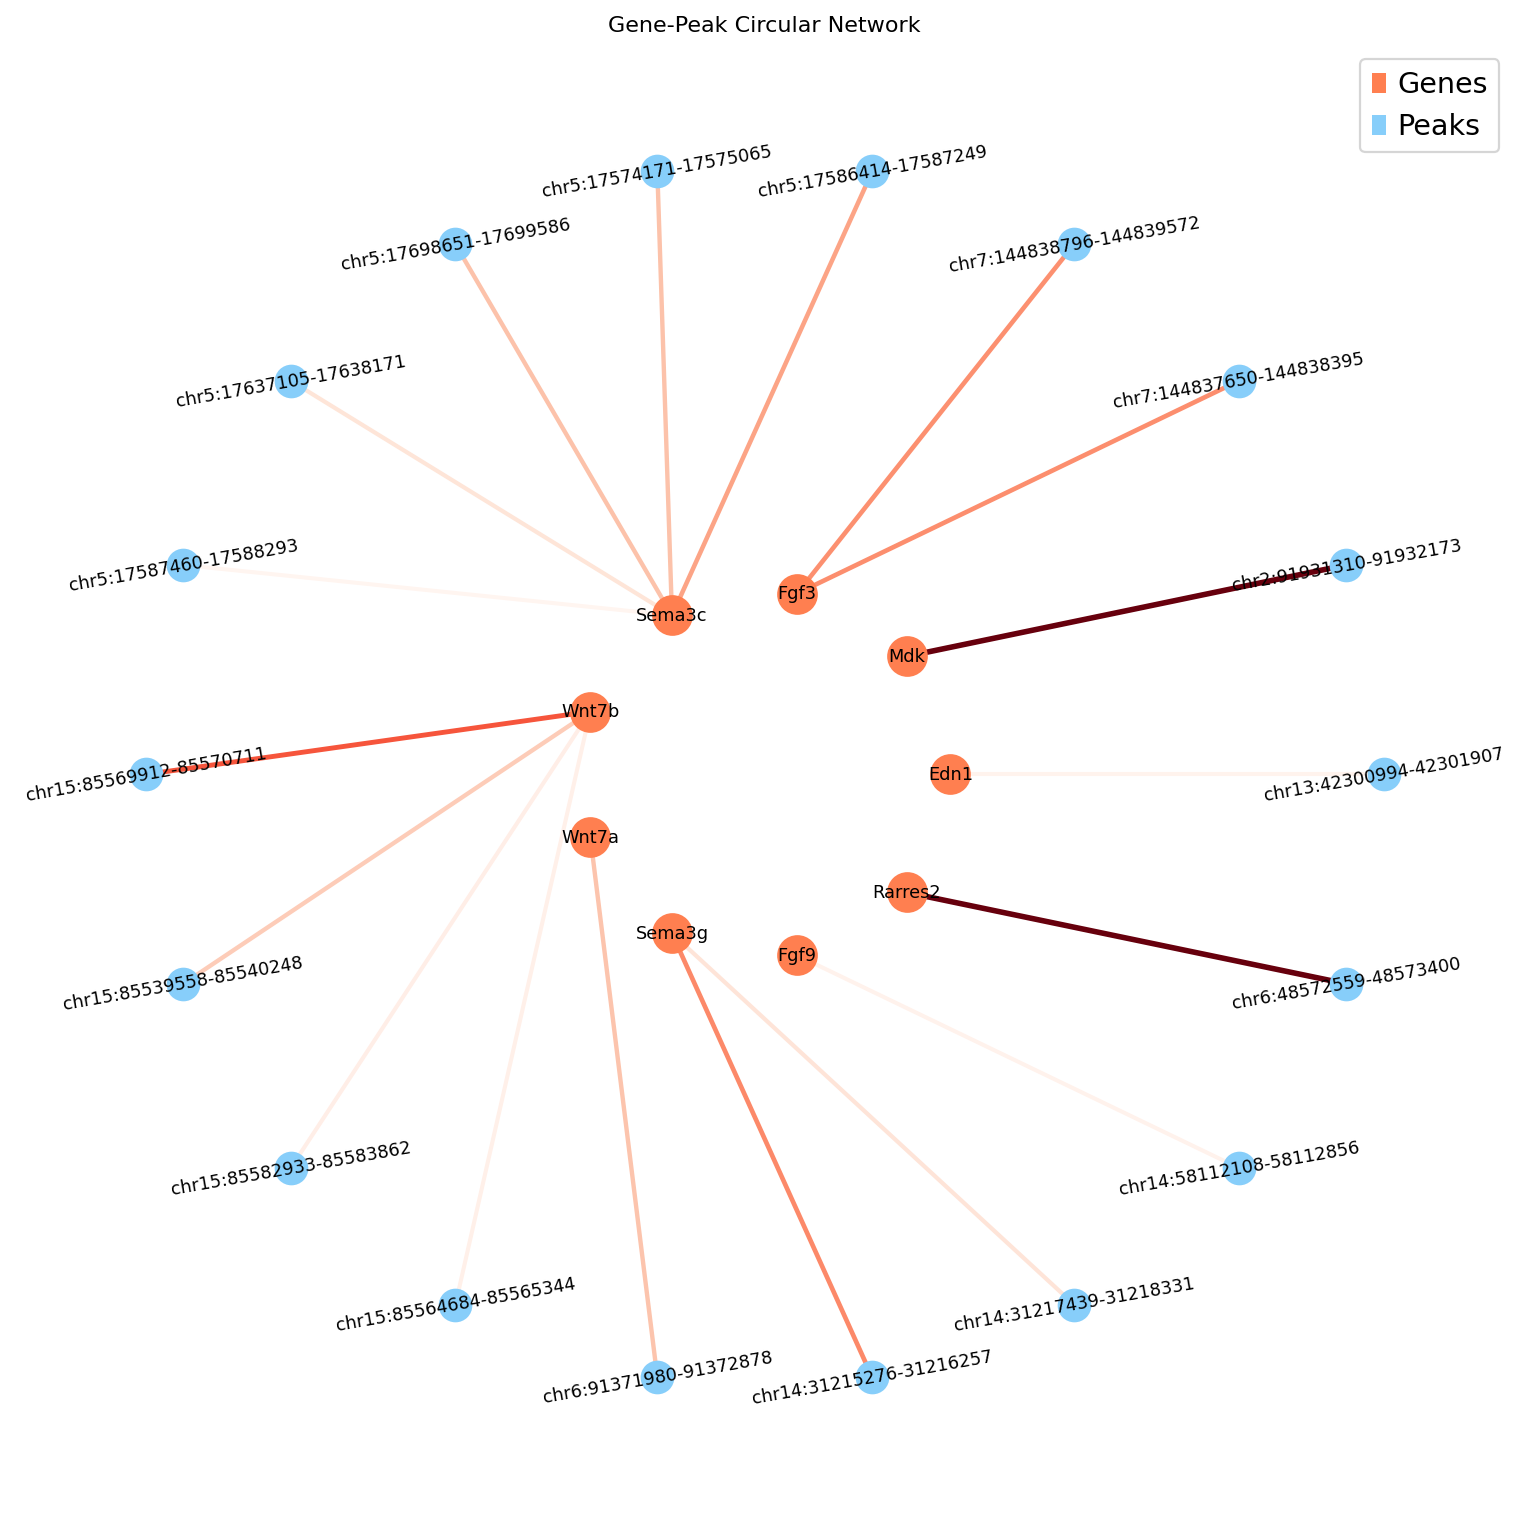

In [127]:
outflow_connect_peaks = signal_related_peaks(network_inflow, network_outflow, gene2peak, top_peaks=10, save_connect_peaks=True, save_path="Edn1_")

In [27]:
peaks_bed = pd.read_csv("peaks.bed", sep='\t', header=None)
peaks_bed

,0,1,2
0,chr1,3094539,3095481
1,chr1,3119728,3120654
2,chr1,3123209,3124083
3,chr1,3147310,3148326
4,chr1,3149755,3150616
...,...,...,...
117468,GL456216.1,34737,35623
117469,GL456216.1,48790,49701
117470,GL456216.1,54146,55035
117471,JH584292.1,12569,13507


In [28]:
gene2peak_links = pd.read_csv("gene2peak.links", sep='\t', header=None)
gene2peak_links

,0,1,2,3,4,5,6
0,chr12,30584425,30584426,chr12,30584134,30585041,1.000000
1,chr3,94443317,94443318,chr3,94442915,94443800,1.000000
2,chr3,132950290,132950291,chr3,132911444,132912331,0.681394
3,chr3,132950290,132950291,chr3,132928502,132929470,0.707142
4,chr3,132950290,132950291,chr3,132934244,132935111,0.708717
...,...,...,...,...,...,...,...
7997,chr15,11064789,11064790,chr15,11165669,11166552,0.796410
7998,chr15,11064789,11064790,chr15,11202847,11203687,0.732058
7999,chr15,11064789,11064790,chr15,11296431,11297348,0.780095
8000,chr15,11064789,11064790,chr15,11316384,11317511,0.669981


In [128]:
%%writefile tracks.ini

[Score]
file = gene2peak.links
title = Score
height = 2
color = YlGnBu
compact_arcs_level = 2
use_middle = False
file_type = links

[ATAC]
file = peaks.bed
title = ATAC
display = collapsed
border_color = none
labels = False
file_type = bed

[Genes]
file = gencode.vM25.chr_patch_hapl_scaff.annotation.gtf.gz
title = Genes
prefered_name = gene_name
height = 2
weight = 4
merge_transcripts = True
labels = True
max_labels = 100
all_labels_inside = True
style = UCSC
file_type = gtf

[x-axis]
fontsize = 12

Overwriting tracks.ini


In [136]:
loc = rna.var.loc["Edn1"]
chrom = loc["chrom"]
chromLen = loc["chromEnd"] - loc["chromStart"]
chromStart = loc["chromStart"] - chromLen
chromEnd = loc["chromEnd"] + chromLen
!pyGenomeTracks --tracks tracks.ini \
    --region {chrom}:{chromStart}-{chromEnd} \
    --dpi 300 \
    --outFileName tracks.png 2> /dev/null

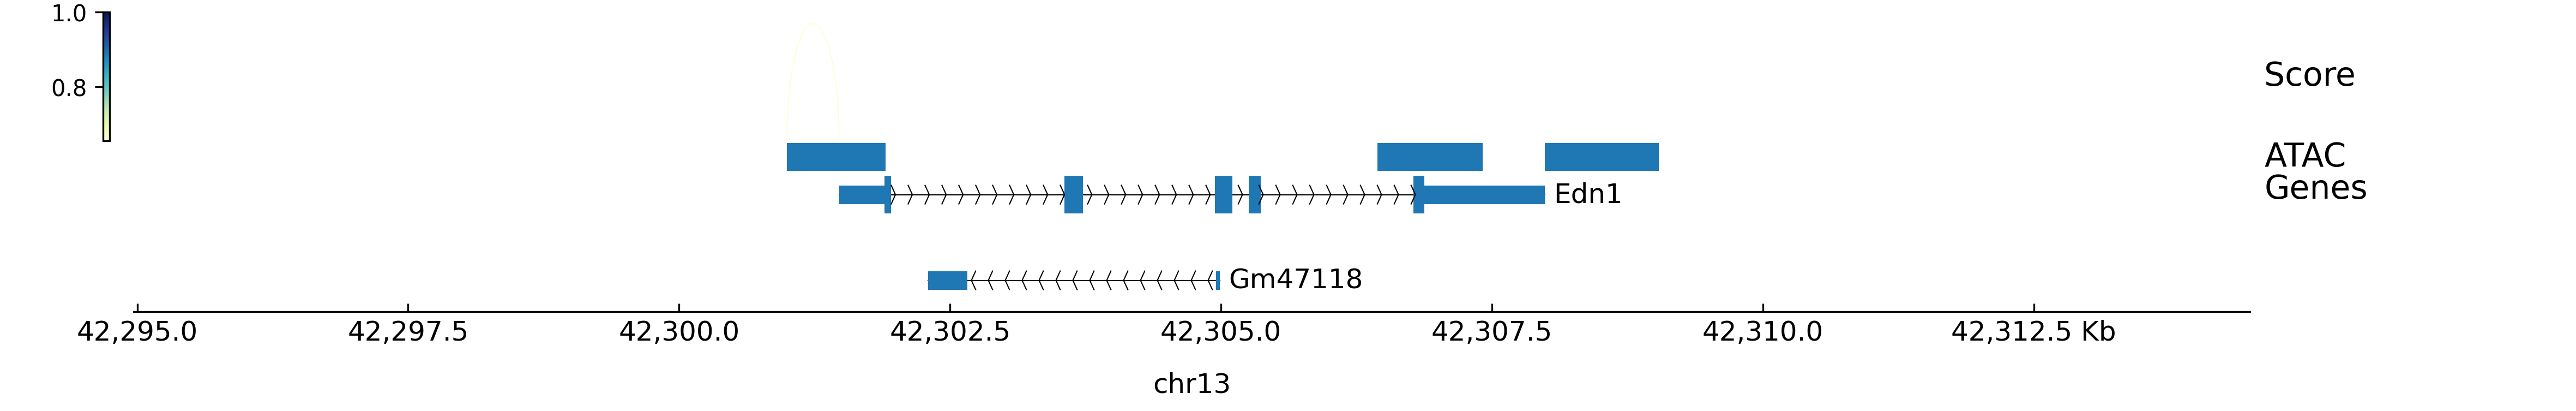

In [137]:
from PIL import Image
img = Image.open("tracks.png")
img.show()